In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
#Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor    
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   
import joblib

In [3]:
file_path ='C:/Users/RichardAnaneSarfo/Desktop/Anane200/ML/Data/job_salary_prediction_dataset.csv'
df = pd.read_csv(file_path)
df.shape

(250000, 10)

In [4]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [4]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [6]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

FEATURE ENGINEERING

In [9]:
# Non-linear experience effects
df['experience_squared'] = df['experience_years'] ** 2
df['experience_cubed'] = df['experience_years'] ** 3

In [10]:
# Interaction features
df['exp_skills_interaction'] = df['experience_years'] * df['skills_count']
df['exp_cert_interaction'] = df['experience_years'] * df['certifications']
df['skills_cert_interaction'] = df['skills_count'] * df['certifications']

In [11]:
# Derived features
df['skills_per_year'] = df['skills_count'] / (df['experience_years'] + 1)
df['total_qualifications'] = df['skills_count'] + (df['certifications'] * 2)


In [23]:
# Experience level bins
df['experience_level'] = pd.cut(df['experience_years'], 
                                 bins=[-1, 2, 5, 10, 15, 20], 
                                 labels=['Entry', 'Junior', 'Mid', 'Senior', 'Expert'])

In [36]:
# Identify categorical columns
categorical_cols = ['job_title', 'education_level', 'industry', 'company_size', 
                    'location', 'remote_work', 'experience_level']
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")

Shape after encoding: (250000, 54)


In [38]:
# Create log-transformed target
df_encoded['log_salary'] = np.log(df_encoded['salary'])
print(f"Original salary range: ${df_encoded['salary'].min():,.0f} - ${df_encoded['salary'].max():,.0f}")
print(f"Log salary range: {df_encoded['log_salary'].min():.2f} - {df_encoded['log_salary'].max():.2f}")

Original salary range: $31,867 - $333,046
Log salary range: 10.37 - 12.72


In [35]:
if 'salary' in categorical_cols:
    categorical_cols.remove('salary')
print("Categorical columns to encode:", categorical_cols)

Categorical columns to encode: ['job_title', 'education_level', 'industry', 'company_size', 'location', 'remote_work', 'experience_level']


In [31]:
df_encoded.head()

,experience_years,skills_count,certifications,salary,experience_squared,experience_cubed,exp_skills_interaction,exp_cert_interaction,skills_cert_interaction,skills_per_year,...,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes,experience_level_Junior,experience_level_Mid,experience_level_Senior,experience_level_Expert,log_salary
0,10,2,2,109413,100,1000,20,20,4,0.181818,...,False,False,False,False,False,False,True,False,False,11.602885
1,5,17,0,93764,25,125,85,0,0,2.833333,...,False,False,False,True,False,True,False,False,False,11.448536
2,18,4,1,148123,324,5832,72,18,4,0.210526,...,False,False,False,True,False,False,False,False,True,11.905798
3,19,13,0,189123,361,6859,247,0,0,0.650000,...,False,False,False,False,True,False,False,False,True,12.150153
4,15,7,0,165069,225,3375,105,0,0,0.437500,...,True,False,False,False,True,False,False,True,False,12.014119


Exploratory Data Analysis (EDA)

Saved: salary_transformation.png


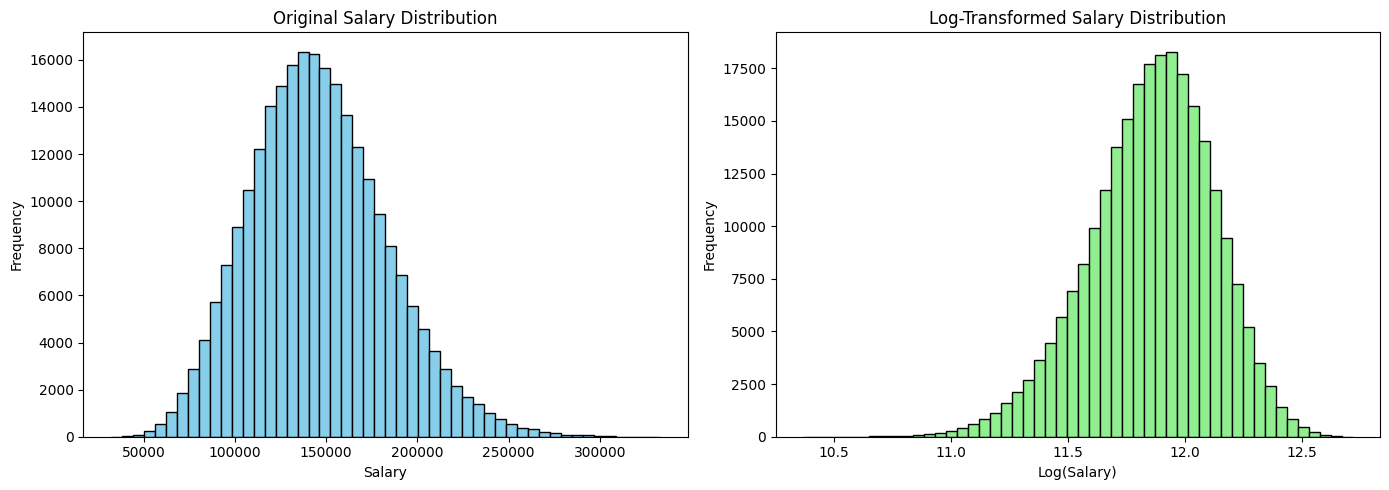

In [39]:
# Visualize transformation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_encoded['salary'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Original Salary Distribution')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

axes[1].hist(df_encoded['log_salary'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Log-Transformed Salary Distribution')
axes[1].set_xlabel('Log(Salary)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('salary_transformation.png', dpi=300, bbox_inches='tight')
print("Saved: salary_transformation.png")
plt.show()

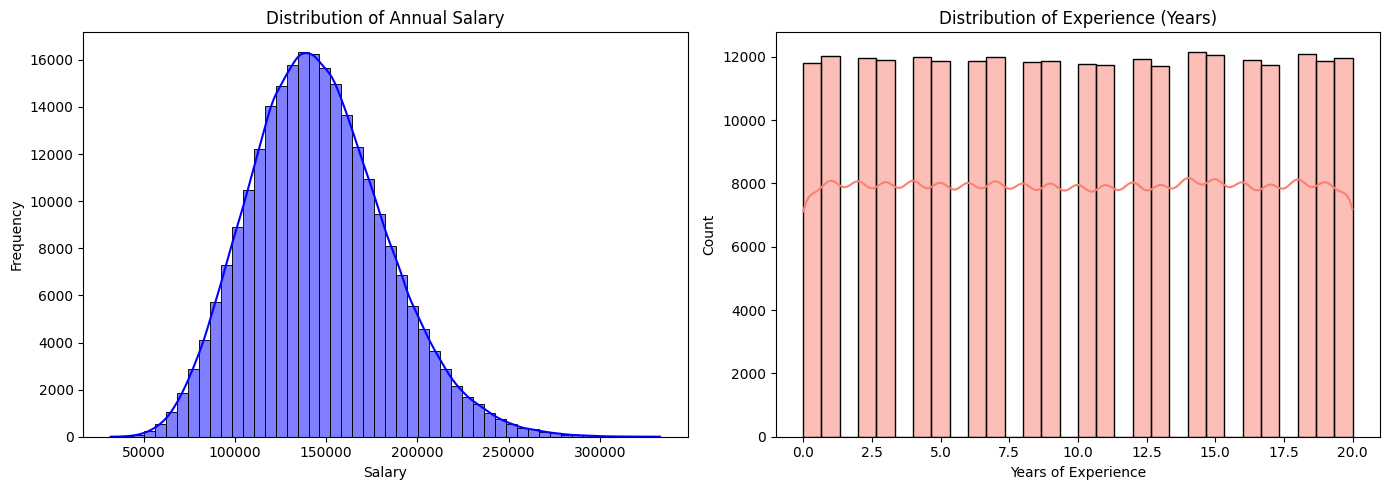

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution – using df['salary']
sns.histplot(df['salary'], bins=50, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Annual Salary')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

# Experience years distribution
sns.histplot(df['experience_years'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Experience (Years)')
axes[1].set_xlabel('Years of Experience')

plt.tight_layout()
plt.show()

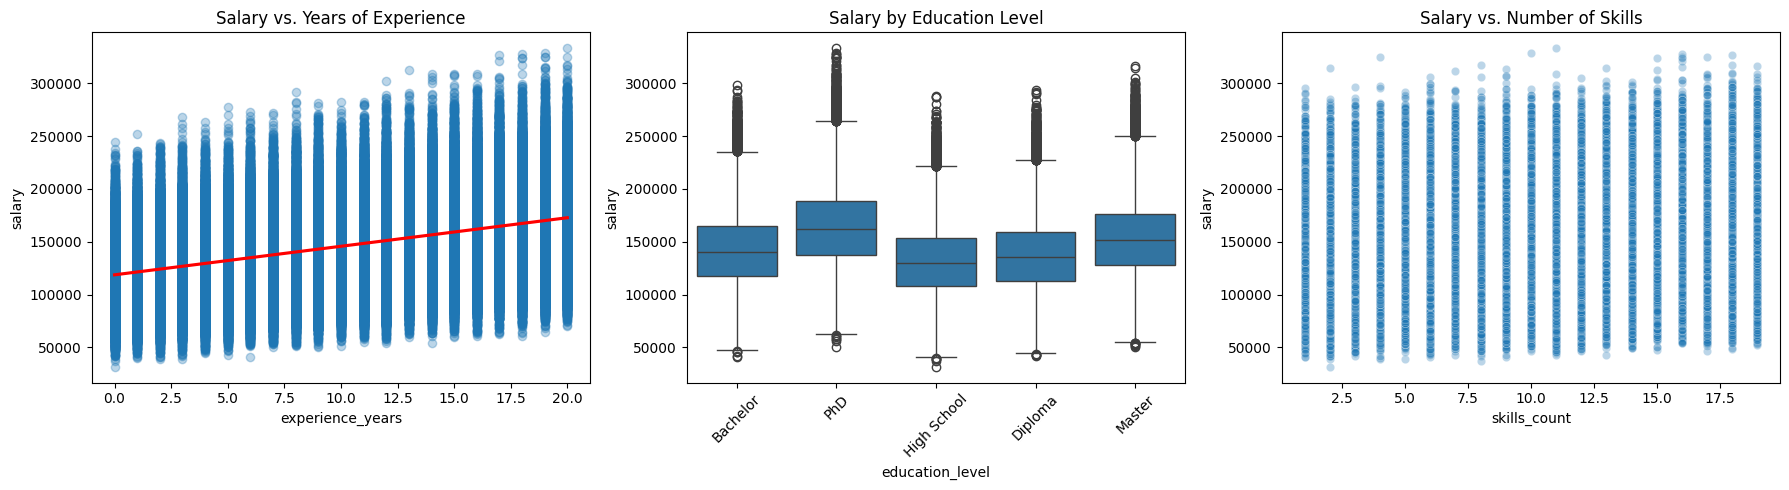

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Salary vs. Experience (scatter + regression line)
sns.regplot(x='experience_years', y='salary', data=df, ax=axes[0], 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Salary vs. Years of Experience')

# Salary vs. Education Level (boxplot)
sns.boxplot(x='education_level', y='salary', data=df, ax=axes[1])
axes[1].set_title('Salary by Education Level')
axes[1].tick_params(axis='x', rotation=45)

# Salary vs. Skills Count (scatter)
sns.scatterplot(x='skills_count', y='salary', data=df, ax=axes[2], alpha=0.3)
axes[2].set_title('Salary vs. Number of Skills')

plt.tight_layout()
plt.show()

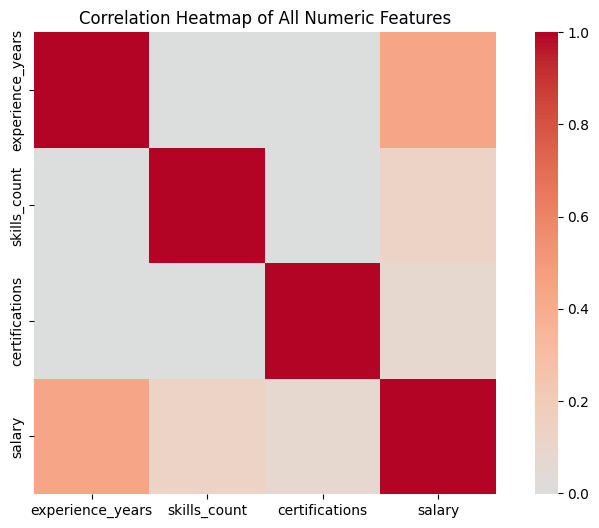

In [12]:
numeric_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of All Numeric Features')
plt.show()

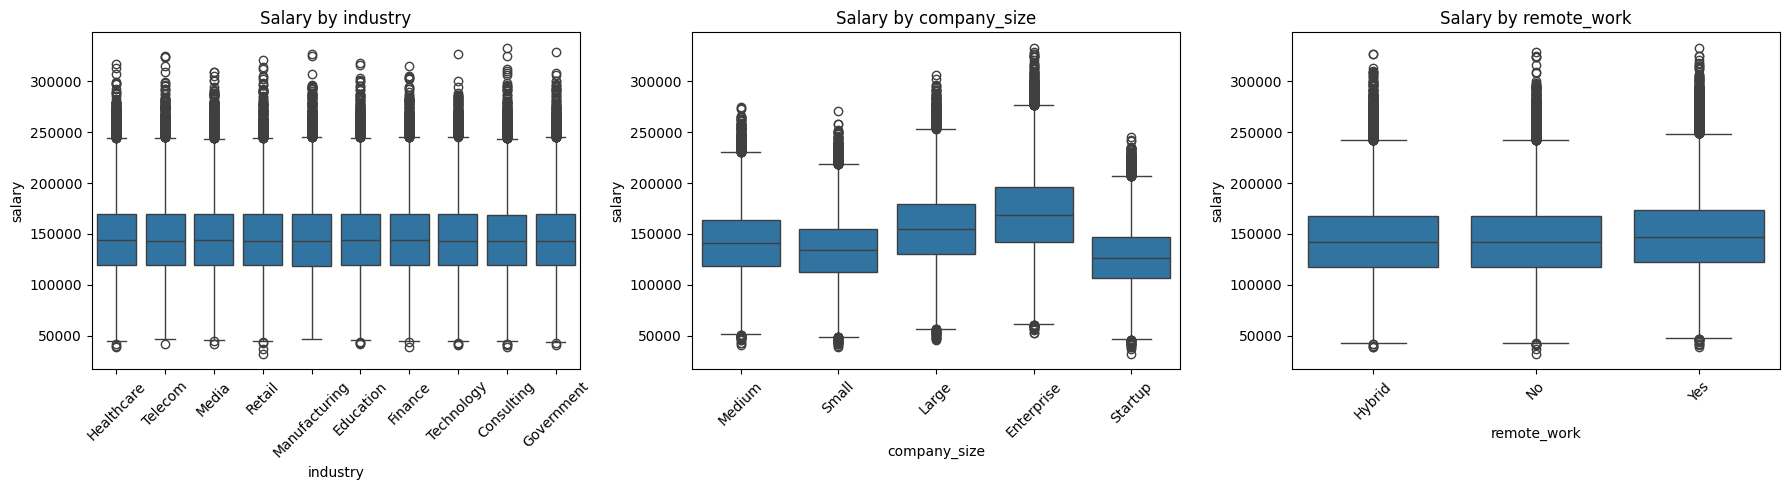

In [13]:
# Boxplots for salary across different categories
cat_features = ['industry', 'company_size', 'remote_work']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(cat_features):
    sns.boxplot(x=col, y='salary', data=df, ax=axes[i])
    axes[i].set_title(f'Salary by {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Features and target
X = df_encoded.drop(['salary', 'log_salary'], axis=1)
y_log = df_encoded['log_salary']  # Use log-transformed target
y_original = df_encoded['salary']  # Keep original for reference

print(f"Features shape: {X.shape}")
print(f"Target shape: {y_log.shape}")

Features shape: (250000, 53)
Target shape: (250000,)


In [45]:
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Also split original salary for evaluation
_, _, y_train_orig, y_test_orig = train_test_split(
    X, y_original, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")



Training set size: 200000 rows
Test set size: 50000 rows


In [46]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    
    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    'LGBM': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=7,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
}

In [48]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train model
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train_log)
        y_pred_log = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train_log)
        y_pred_log = model.predict(X_test)
    
    # Transform predictions back to original scale
    y_pred_original = np.exp(y_pred_log)
    
    # Calculate metrics on original scale
    mae = mean_absolute_error(y_test_orig, y_pred_original)
    mse = mean_squared_error(y_test_orig, y_pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_orig, y_pred_original)
    
    # Calculate metrics on log scale
    mae_log = mean_absolute_error(y_test_log, y_pred_log)
    r2_log = r2_score(y_test_log, y_pred_log)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAE_log': mae_log,
        'R²_log': r2_log,
        'model': model,
        'predictions_log': y_pred_log,
        'predictions_original': y_pred_original
    }
    
    print(f"  MAE: ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  R²: {r2:.4f}")



Training Linear Regression...
  MAE: $4,541.57
  RMSE: $5,732.94
  R²: 0.9764

Training Random Forest...
  MAE: $8,878.54
  RMSE: $11,619.30
  R²: 0.9029

Training Gradient Boosting...
  MAE: $4,416.35
  RMSE: $5,577.40
  R²: 0.9776

Training XGBoost...
  MAE: $4,196.94
  RMSE: $5,266.43
  R²: 0.9800

Training LGBM...
  MAE: $4,205.18
  RMSE: $5,276.13
  R²: 0.9800


Evaluation & Comparison of Models

In [50]:
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'R²': [results[m]['R²'] for m in results.keys()]
})

results_df = results_df.sort_values('R²', ascending=False)
print("\n", results_df.to_string(index=False))



             Model         MAE         RMSE       R²
          XGBoost 4196.939453  5266.432569 0.980045
             LGBM 4205.180386  5276.125613 0.979971
Gradient Boosting 4416.352055  5577.396458 0.977618
Linear Regression 4541.574614  5732.937388 0.976353
    Random Forest 8878.536536 11619.303004 0.902862



Saved: model_comparison_improved.png


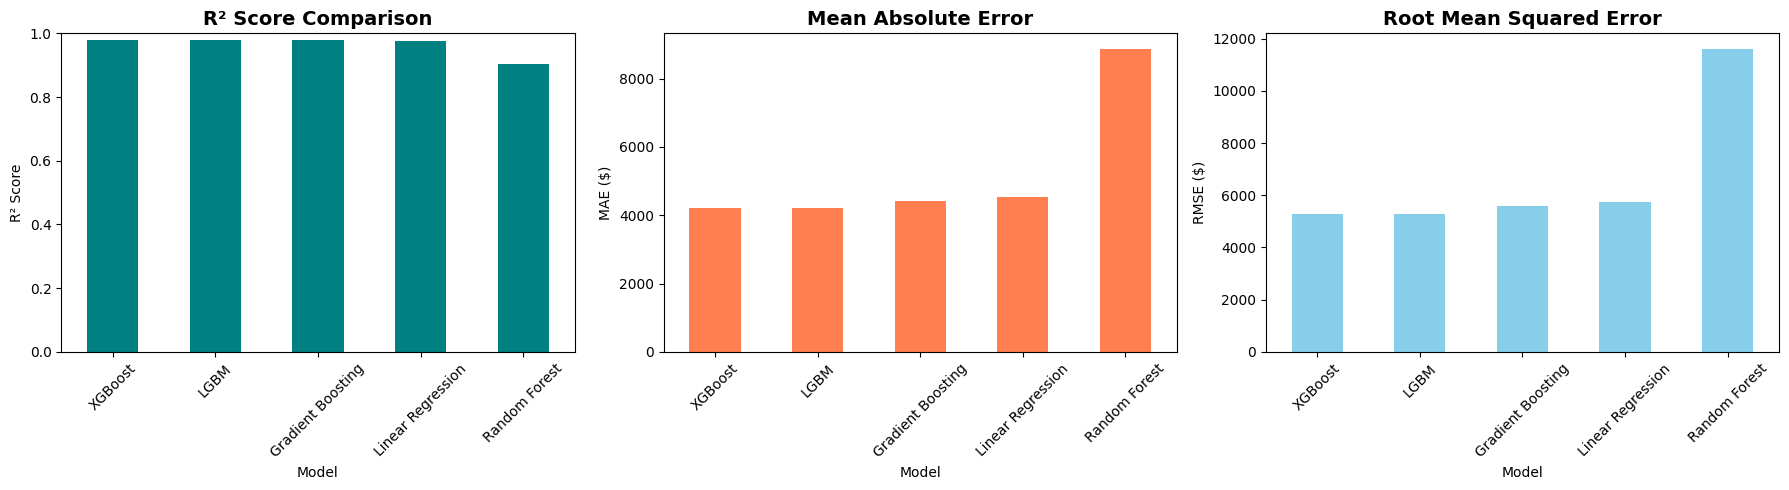

In [51]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R² Score
results_df.plot(x='Model', y='R²', kind='bar', ax=axes[0], color='teal', legend=False)
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# MAE
results_df.plot(x='Model', y='MAE', kind='bar', ax=axes[1], color='coral', legend=False)
axes[1].set_title('Mean Absolute Error', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE ($)')
axes[1].tick_params(axis='x', rotation=45)

# RMSE
results_df.plot(x='Model', y='RMSE', kind='bar', ax=axes[2], color='skyblue', legend=False)
axes[2].set_title('Root Mean Squared Error', fontsize=14, fontweight='bold')
axes[2].set_ylabel('RMSE ($)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('model_comparison_improved.png', dpi=300, bbox_inches='tight')
print("\nSaved: model_comparison_improved.png")
plt.show()

In [52]:
best_model_name = results_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['predictions_original']

print(f"\nBest Model: {best_model_name}")
print(f"R² Score: {results[best_model_name]['R²']:.4f}")
print(f"MAE: ${results[best_model_name]['MAE']:,.2f}")
print(f"RMSE: ${results[best_model_name]['RMSE']:,.2f}")


Best Model: XGBoost
R² Score: 0.9800
MAE: $4,196.94
RMSE: $5,266.43


Saved: residuals_improved.png


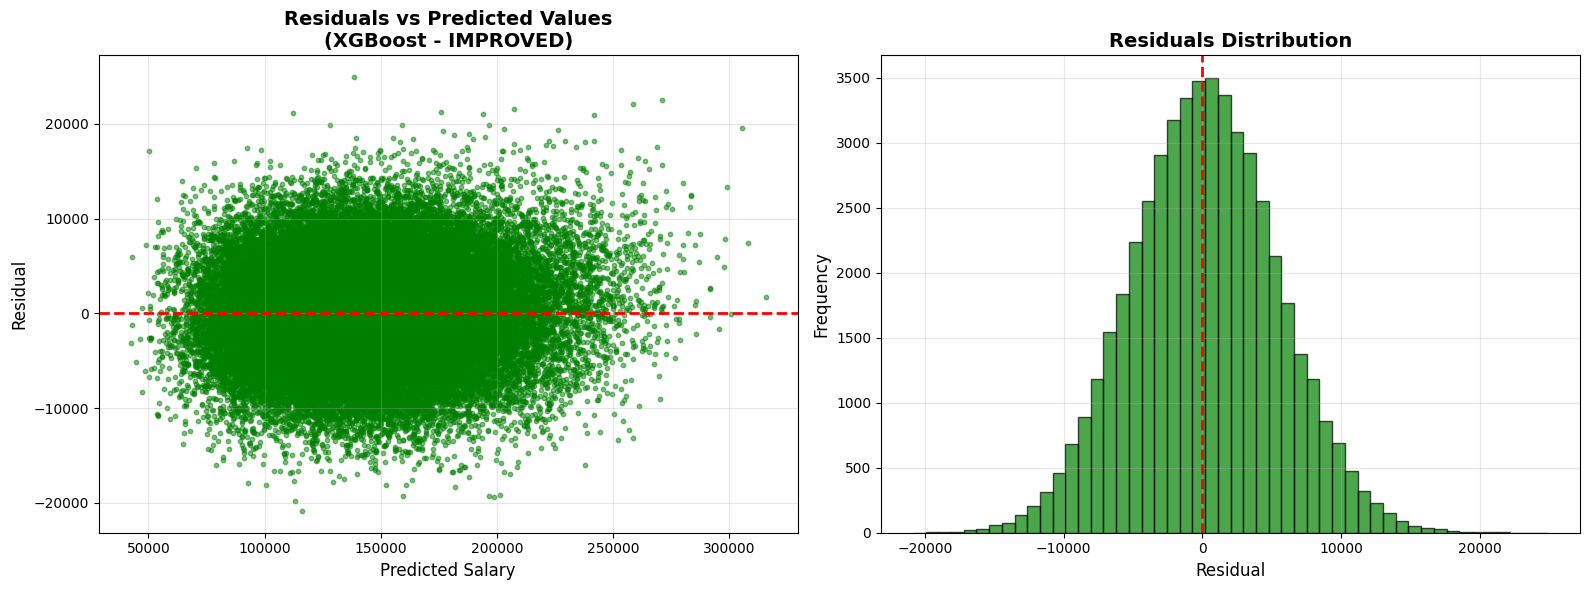

In [53]:

residuals = y_test_orig - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.5, s=10, color='green')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Salary', fontsize=12)
axes[0].set_ylabel('Residual', fontsize=12)
axes[0].set_title(f'Residuals vs Predicted Values\n({best_model_name} - IMPROVED)', 
                  fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residual', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Residuals Distribution', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('residuals_improved.png', dpi=300, bbox_inches='tight')
print("Saved: residuals_improved.png")
plt.show()

Saved: actual_vs_predicted_improved.png


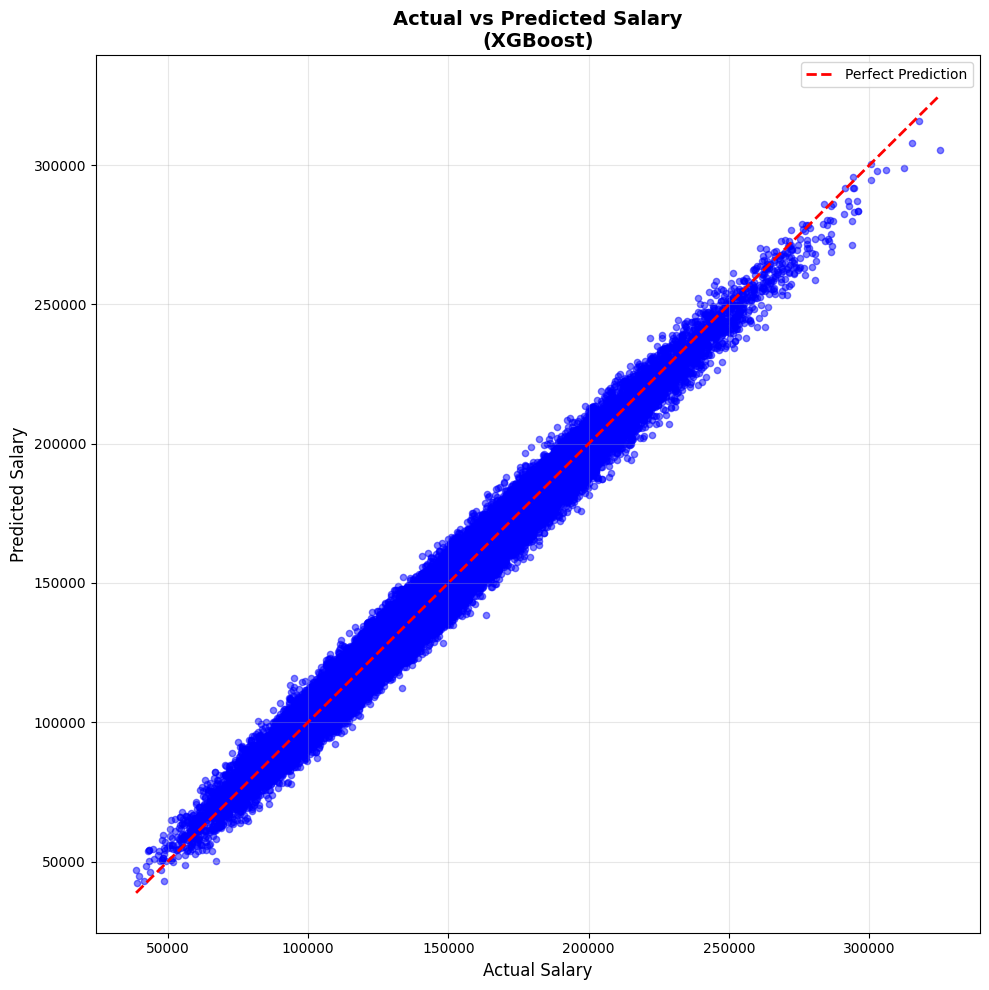

In [55]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(y_test_orig, y_pred_best, alpha=0.5, s=20, color='blue')
ax.plot([y_test_orig.min(), y_test_orig.max()], 
        [y_test_orig.min(), y_test_orig.max()], 
        'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Salary', fontsize=12)
ax.set_ylabel('Predicted Salary', fontsize=12)
ax.set_title(f'Actual vs Predicted Salary\n({best_model_name})', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted_improved.png', dpi=300, bbox_inches='tight')
print("Saved: actual_vs_predicted_improved.png")
plt.show()


Saved: feature_importance.png


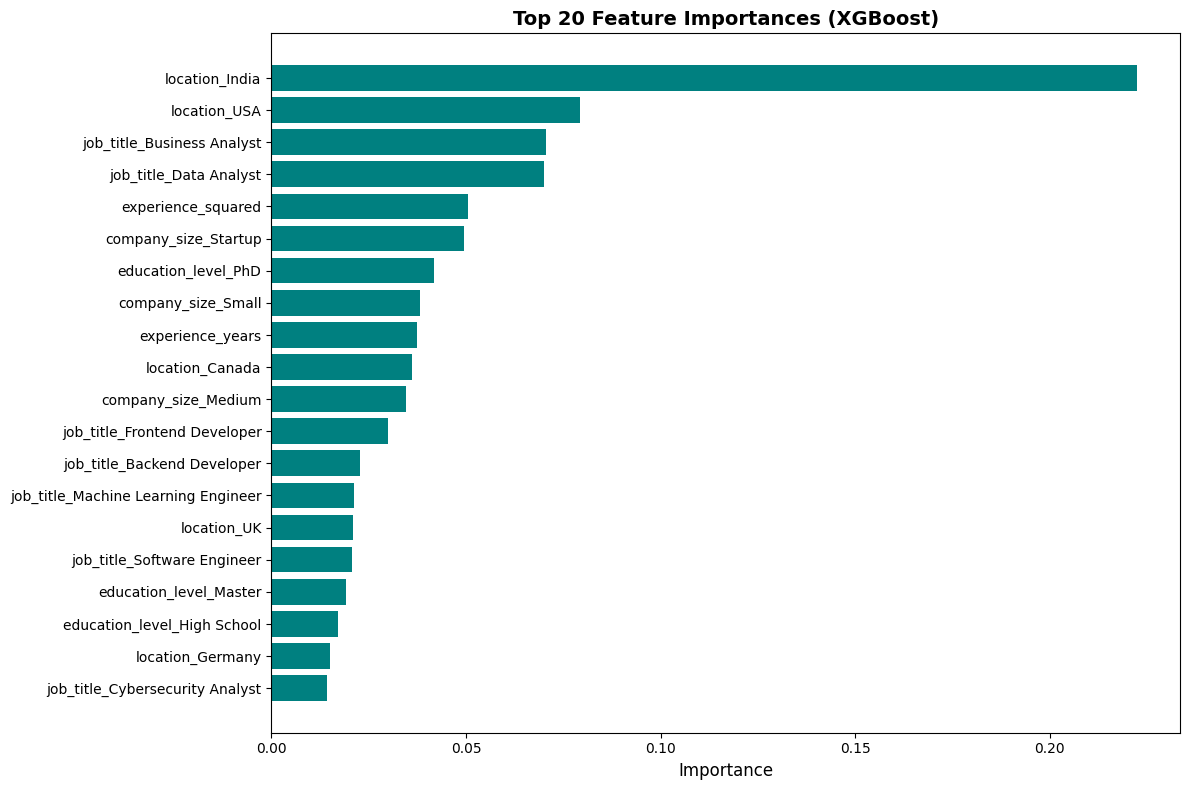

In [56]:
feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(20)
    
    
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.xlabel('Importance', fontsize=12)
plt.title(f'Top 20 Feature Importances ({best_model_name})', 
              fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\nSaved: feature_importance.png")
plt.show()

Best Model Selection & Saving with Joblib

In [58]:
joblib.dump(best_model, 'best_salary_model_improved.joblib')
joblib.dump(scaler, 'scaler_improved.joblib')

print(f"Saved: best_salary_model_improved.joblib")
print(f"Saved: scaler_improved.joblib")

Saved: best_salary_model_improved.joblib
Saved: scaler_improved.joblib
